## В этом модуле, мы разберемся с задачей, начнем исследовать данные

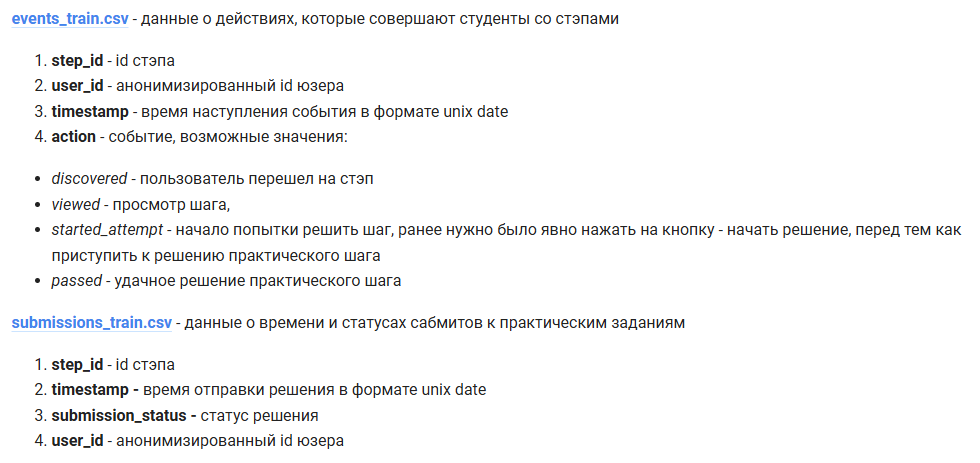

In [23]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
!wget https://stepik.org/media/attachments/course/4852/event_data_train.zip -q

In [25]:
!unzip /content/event_data_train.zip -d data

Archive:  /content/event_data_train.zip
replace data/event_data_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/event_data_train.csv  


In [26]:
events_data = pd.read_csv('/content/data/event_data_train.csv')
events_data.head()

,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


In [27]:
events_data.action.unique()

array(['viewed', 'passed', 'discovered', 'started_attempt'], dtype=object)

'viewed' - посмотреть, 'passed' - решить, 'discovered' - впервые увидеть, 'started_attempt' - начать решать

In [28]:
events_data['date'] = pd.to_datetime(events_data.timestamp, unit = 's')
events_data.head()

,step_id,timestamp,action,user_id,date
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48
1,32815,1434340848,passed,17632,2015-06-15 04:00:48
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35


In [29]:
events_data.dtypes

,0
step_id,int64
timestamp,int64
action,object
user_id,int64
date,datetime64[ns]


In [30]:
events_data.date.min()

Timestamp('2015-06-15 04:00:48')

In [31]:
events_data.date.max()

Timestamp('2018-05-19 23:33:31')

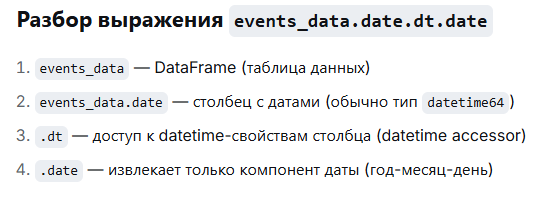

In [32]:
events_data['day'] = events_data.date.dt.date
events_data.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


##### Сколько человек и в какой день записалось

In [33]:
events_data.groupby('day', as_index=False) \
           .user_id.nunique() \
           .head()

,day,user_id
0,2015-06-15,705
1,2015-06-16,526
2,2015-06-17,440
3,2015-06-18,411
4,2015-06-19,377


<Axes: xlabel='day'>

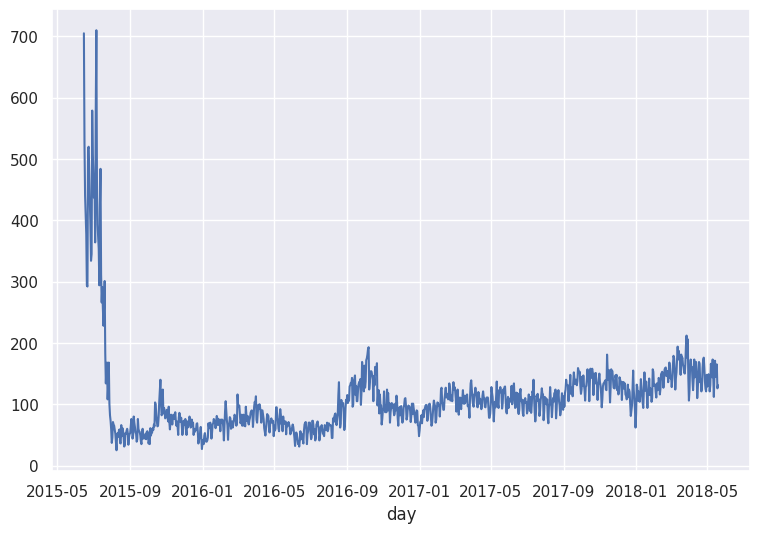

In [34]:
events_data.groupby('day') \
           .user_id.nunique() \
           .plot()

In [ ]:
# Надстройка для изменения размера графика
sns.set(rc={'figure.figsize': (9,6)})

<Axes: xlabel='day'>

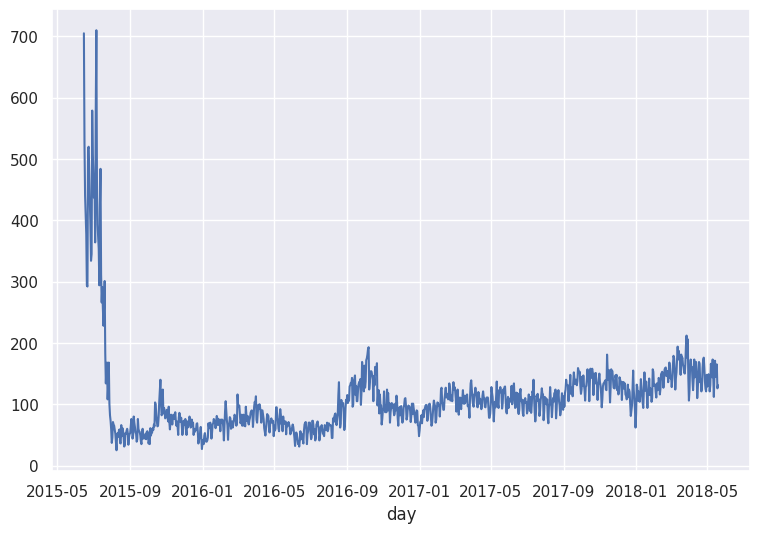

In [35]:
events_data.groupby('day') \
           .user_id.nunique() \
           .plot()

#### Распределение пользователей по количеству баллов

<Axes: >

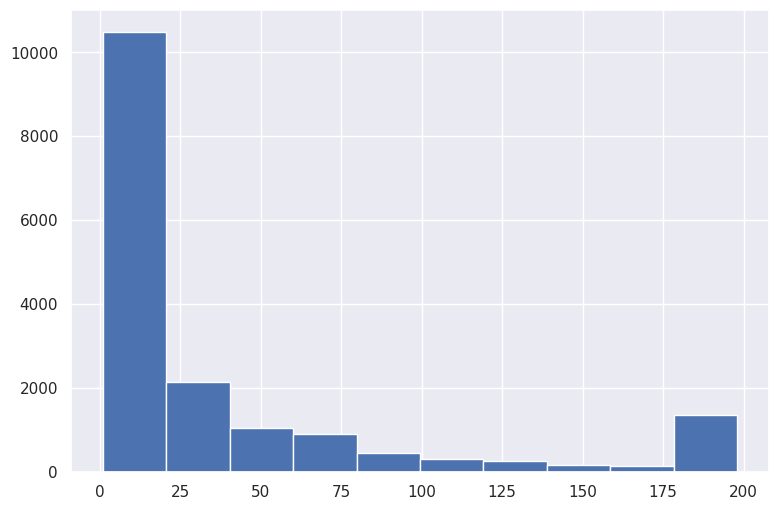

In [36]:
events_data[events_data.action == 'passed'] \
    .groupby('user_id', as_index = False) \
    .agg({'step_id': 'count'}) \
    .rename(columns = {'step_id': 'passed_step'}) \
    .passed_step.hist()

In [37]:
events_data[events_data.action == 'passed'] \
    .groupby('user_id', as_index = False) \
    .agg({'step_id': 'count'}) \
    .rename(columns = {'step_id': 'passed_step'}) \
    .passed_step.min()

1

In [68]:
# включаем 0 в выборку
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0) \
            .head()

action,discovered,passed,started_attempt,viewed
user_id,,,,
1,1,0,0,1
2,9,9,2,10
3,91,87,30,192
5,11,11,4,12
7,1,1,0,1


In [69]:
            # включаем 0 в выборку
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0) \
            .rename_axis('', axis=1) \
            .head()

,discovered,passed,started_attempt,viewed
user_id,,,,
1,1,0,0,1
2,9,9,2,10
3,91,87,30,192
5,11,11,4,12
7,1,1,0,1


In [70]:
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0) \
            .reset_index() \
            .head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


In [71]:
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0) \
            .reset_index() \
            .rename_axis('', axis=1) \
            .head()

,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


<Axes: >

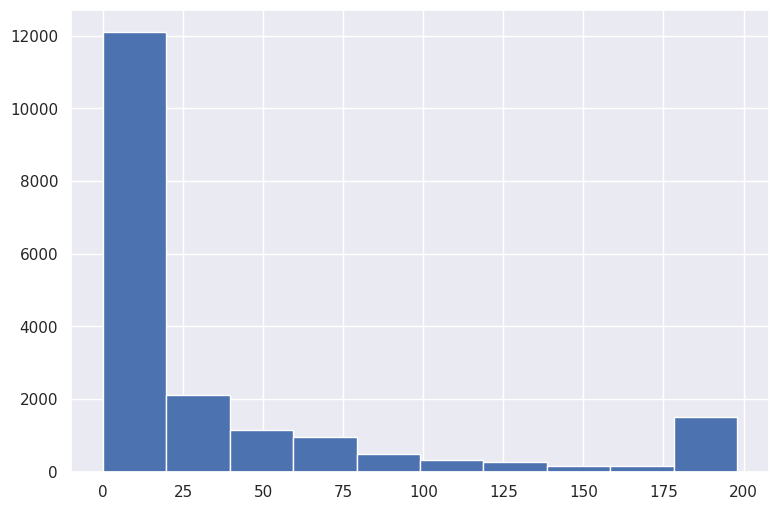

In [39]:
events_data.pivot_table(index='user_id',
                        columns='action',
                        values='step_id',
                        aggfunc='count',
                        fill_value=0)\
            .reset_index()\
            .discovered.hist()

#В этом модуле, мы продолжаем разбираться с задачей, начнем исследовать данные

In [75]:
!wget https://stepik.org/media/attachments/course/4852/submissions_data_train.zip -q
!unzip /content/submissions_data_train.zip -d data

submissions_data = pd.read_csv('/content/data/submissions_data_train.csv') #указываете свой путь
submissions_data.head()

Archive:  /content/submissions_data_train.zip
replace data/submissions_data_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/submissions_data_train.csv  


,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


In [76]:
submissions_data['date'] = pd.to_datetime(submissions_data.timestamp, unit = 's')
submissions_data['day'] = submissions_data.date.dt.date
submissions_data.head()

,step_id,timestamp,submission_status,user_id,date,day
0,31971,1434349275,correct,15853,2015-06-15 06:21:15,2015-06-15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00,2015-06-15
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49,2016-11-11
3,31972,1478852164,correct,15853,2016-11-11 08:16:04,2016-11-11
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03,2015-06-15


In [77]:
users_scores = submissions_data.pivot_table(index='user_id',
                                            columns='submission_status',
                                            values='step_id',
                                            aggfunc='count',
                                            fill_value=0) \
                               .reset_index() \
                               .rename_axis('', axis=1)
users_scores.head()

,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


##Определение бросивших курс посредством анализа промежутка времени зная который можно утверждать, что студент бросил курс

In [78]:
events_data[['user_id', 'day', 'timestamp']].head()

,user_id,day,timestamp
0,17632,2015-06-15,1434340848
1,17632,2015-06-15,1434340848
2,17632,2015-06-15,1434340848
3,17632,2015-06-15,1434340895
4,17632,2015-06-15,1434340895


Как работает drop_duplicates() ?

In [44]:
events_data[['user_id', 'day', 'timestamp']].head().drop_duplicates()

,user_id,day,timestamp
0,17632,2015-06-15,1434340848
3,17632,2015-06-15,1434340895


In [74]:
# Удаляем дубликаты только по айди и дням
events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']).head()

,user_id,day,timestamp
0,17632,2015-06-15,1434340848
36,12494,2015-06-15,1434341931
59,442,2015-06-15,1434342029
62,22254,2015-06-15,1434342042
94,6646,2015-06-15,1434342230


In [88]:
# на экране ничего  не отобразится
events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']) \
                                            .groupby('user_id')

In [89]:
# Для каждого пользователя находим уникальные таймстемпы
# ['timestamp'].apply(list) применить функцию "построить список" к колонке
events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']) \
                                            .groupby('user_id')['timestamp'].apply(list) \
                                            .head()

,timestamp
user_id,
1,[1472827464]
2,"[1514383364, 1519226966]"
3,"[1434358476, 1441257725, 1441440209, 144153391..."
5,"[1466156809, 1499859621]"
7,[1521634660]


In [90]:
# Для каждого пользователя находим разницу по времени между степами
# .apply(np.diff) применить функцию к колонке в которой уже хранится список
# то есть посчитать разницу между соседними элементами списка
events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']) \
                                            .groupby('user_id')['timestamp'].apply(list).apply(np.diff) \
                                            .head()

,timestamp
user_id,
1,[]
2,[4843602]
3,"[6899249, 182484, 93710, 2768870, 171400, 78712]"
5,[33702812]
7,[]


In [102]:
# Для каждого пользователя находим разницу по времени между степами
gap_data = events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']) \
                                                       .groupby('user_id')['timestamp'] \
                                                       .apply(list) \
                                                       .apply(np.diff).values
for i, item in enumerate(gap_data[:5]):
    print(f"{i}: {item}")

0: []
1: [4843602]
2: [6899249  182484   93710 2768870  171400   78712]
3: [33702812]
4: []


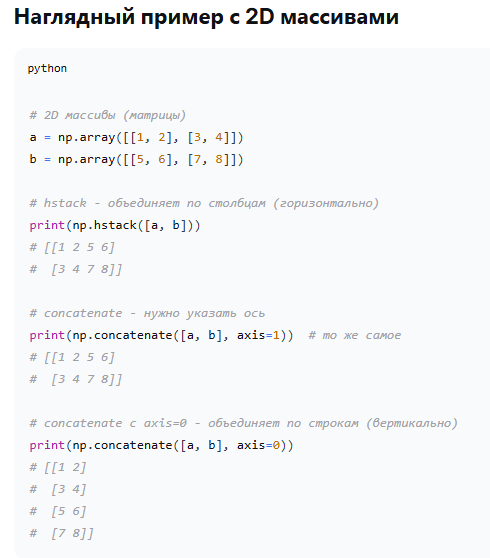

In [110]:
# 2D массивы (матрицы)
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(a)
print(b)

[[1 2]
 [3 4]]
[[5 6]
 [7 8]]


In [109]:
# hstack - объединяет по столбцам (горизонтально)
print(np.hstack([a, b]))
# [[1 2 5 6]
#  [3 4 7 8]]

[[1 2 5 6]
 [3 4 7 8]]


In [111]:
# concatenate - нужно указать ось
print(np.concatenate([a, b], axis=1))  # то же самое
# [[1 2 5 6]
#  [3 4 7 8]]

[[1 2 5 6]
 [3 4 7 8]]


In [112]:
# concatenate с axis=0 - объединяет по строкам (вертикально)
print(np.concatenate([a, b], axis=0))
# [[1 2]
#  [3 4]
#  [5 6]
#  [7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]


In [107]:
np.concatenate(gap_data)

array([4843602, 6899249,  182484, ...,   98252,   57019, 1567990])

In [103]:
np.hstack(gap_data)

array([4843602, 6899249,  182484, ...,   98252,   57019, 1567990])

In [113]:
gap_data = pd.Series(np.hstack(gap_data))
gap_data = gap_data / (24 * 60 * 60)
gap_data.head()

,0
0,56.060208
1,79.852419
2,2.112083
3,1.084606
4,32.047106


<Axes: >

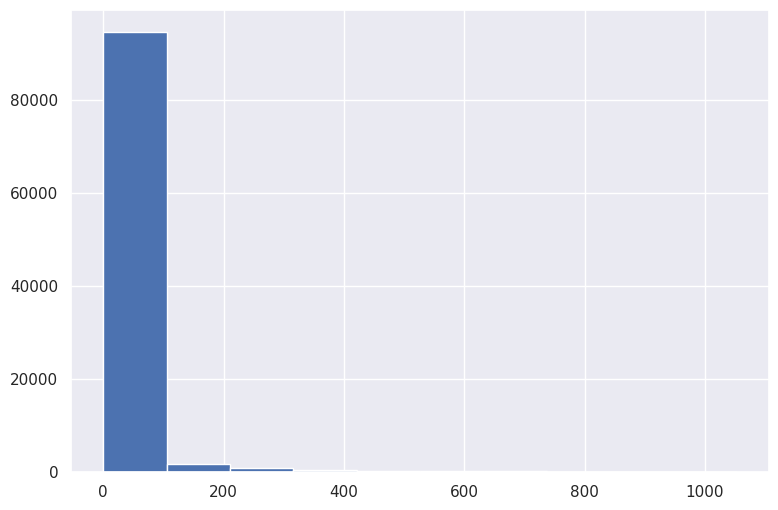

In [114]:
gap_data.hist()

<Axes: >

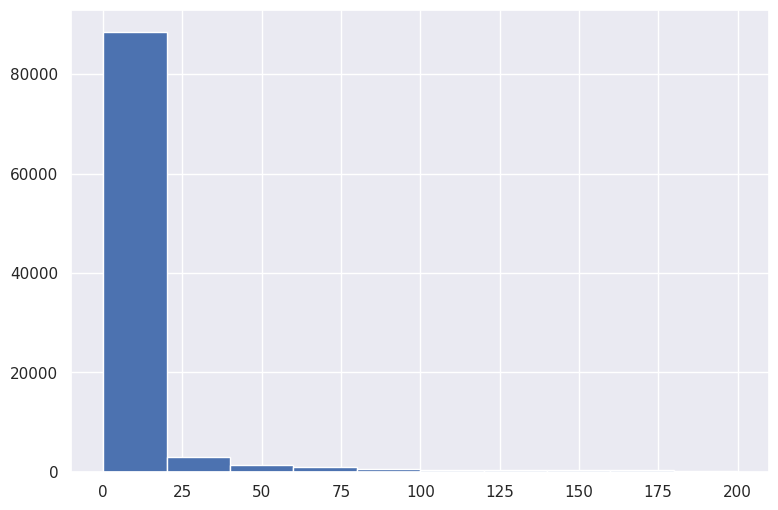

In [115]:
gap_data[gap_data < 200].hist()

<Axes: >

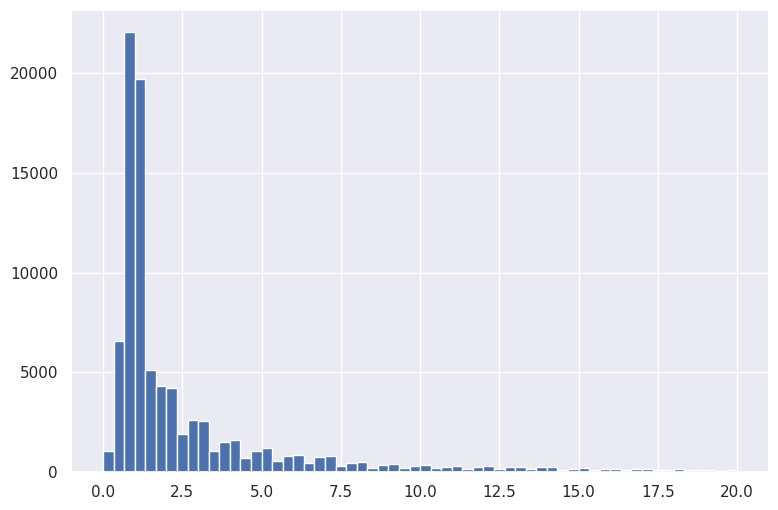

In [129]:
gap_data[gap_data < 20].hist(bins=60)

In [117]:
# только 5% возвращается спустя 2 месяца (59 дней)
gap_data.quantile(0.95)

np.float64(59.760440972222156)

In [130]:
# 90% возвращается спустя 18 дней, 10% более чем через 18 дней
gap_data.quantile(0.9)

np.float64(18.325995370370403)

<Axes: >

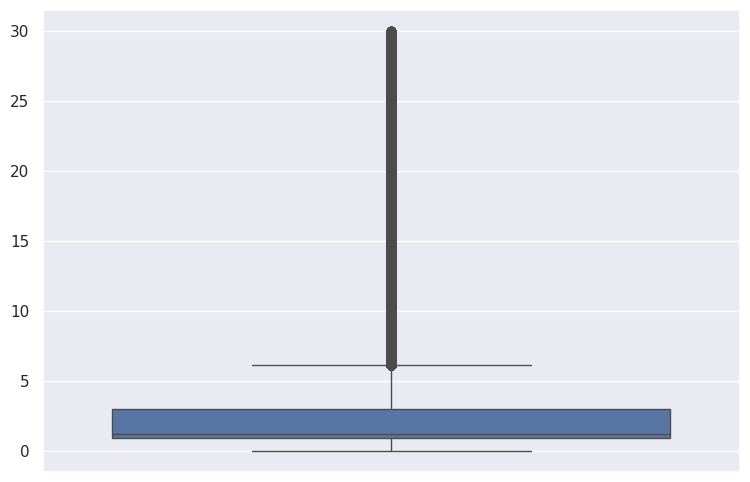

In [135]:
sns.boxplot(gap_data[gap_data < 30])

In [136]:
events_data.groupby('user_id', as_index=False) \
           .agg({'timestamp': 'max'}) \
           .head()

,user_id,timestamp
0,1,1472827464
1,2,1519226966
2,3,1444581588
3,5,1499859939
4,7,1521634660


In [137]:
# максимальный таймстемп
30 * 24 * 60 * 60

2592000

In [138]:
users_data = events_data.groupby('user_id', as_index=False) \
                        .agg({'timestamp': 'max'}) \
                        .rename(columns={'timestamp': 'last_timestamp'})
users_data.head()

,user_id,last_timestamp
0,1,1472827464
1,2,1519226966
2,3,1444581588
3,5,1499859939
4,7,1521634660


In [139]:
now = 1526772811
drop_out_treshold = 2592000

In [140]:
users_data['is_gone_user'] = (now - users_data.last_timestamp) > drop_out_treshold
users_data.head()

,user_id,last_timestamp,is_gone_user
0,1,1472827464,True
1,2,1519226966,True
2,3,1444581588,True
3,5,1499859939,True
4,7,1521634660,True


In [141]:
users_scores.head()

,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


In [142]:
# по умолчанию приметяется inner и пропадут юзеры, у которых в users_scores не было ни одного сабмита
users_data.merge(users_scores).head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,2,1519226966,True,2,0
1,3,1444581588,True,29,23
2,5,1499859939,True,2,2
3,8,1481466913,True,9,21
4,14,1436368676,True,0,1


In [143]:
users_data.merge(users_scores, how='outer').head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,NaN,NaN
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,NaN,NaN


In [144]:
# по умолчанию merge ищет столбец с одинаковым названием
# on='user_id' прямо указывает колонку
users_data.merge(users_scores, on='user_id', how='outer').head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,NaN,NaN
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,NaN,NaN


In [145]:
users_data = users_data.merge(users_scores, on='user_id', how='outer')
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,NaN,NaN
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,NaN,NaN


In [146]:
users_data = users_data.fillna(0)
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,0.0,0.0
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,0.0,0.0


In [147]:
users_events_data = events_data.pivot_table(index='user_id',
                                            columns='action',
                                            values='step_id',
                                            aggfunc='count',
                                            fill_value=0) \
                               .reset_index()
users_events_data.head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


In [148]:
users_data = users_data.merge(users_events_data, on='user_id', how='outer')
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed
0,1,1472827464,True,0.0,0.0,1,0,0,1
1,2,1519226966,True,2.0,0.0,9,9,2,10
2,3,1444581588,True,29.0,23.0,91,87,30,192
3,5,1499859939,True,2.0,2.0,11,11,4,12
4,7,1521634660,True,0.0,0.0,1,1,0,1


In [149]:
users_days = events_data.groupby('user_id').day.nunique()
users_days.head()

,day
user_id,
1,1
2,2
3,7
5,2
7,1


In [150]:
users_data = users_data.merge(users_days, on='user_id', how='outer')
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day
0,1,1472827464,True,0.0,0.0,1,0,0,1,1
1,2,1519226966,True,2.0,0.0,9,9,2,10,2
2,3,1444581588,True,29.0,23.0,91,87,30,192,7
3,5,1499859939,True,2.0,2.0,11,11,4,12,2
4,7,1521634660,True,0.0,0.0,1,1,0,1,1


Проверяем не потеряли ли кого-нибудь?

In [153]:
users_data.user_id.nunique()

19234

In [154]:
events_data.user_id.nunique()

19234

Сколько человек прошло курс?

In [156]:
users_data['passed_course'] = users_data.passed > 170
users_data.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day,passed_course
0,1,1472827464,True,0.0,0.0,1,0,0,1,1,False
1,2,1519226966,True,2.0,0.0,9,9,2,10,2,False
2,3,1444581588,True,29.0,23.0,91,87,30,192,7,False
3,5,1499859939,True,2.0,2.0,11,11,4,12,2,False
4,7,1521634660,True,0.0,0.0,1,1,0,1,1,False


In [157]:
users_data.groupby('passed_course').count()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day
passed_course,,,,,,,,,,
False,17809,17809,17809,17809,17809,17809,17809,17809,17809,17809
True,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425


In [158]:
# 100*1425/17809 - доля прошедших курс
users_data['passed_course'].value_counts(normalize=True)*100 # второй способ

,proportion
passed_course,
False,92.591245
True,7.408755
